In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Airbnb_data.csv")

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


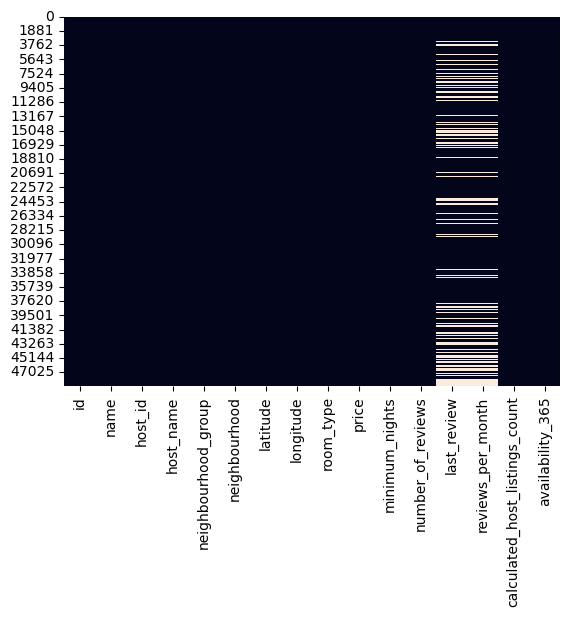

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

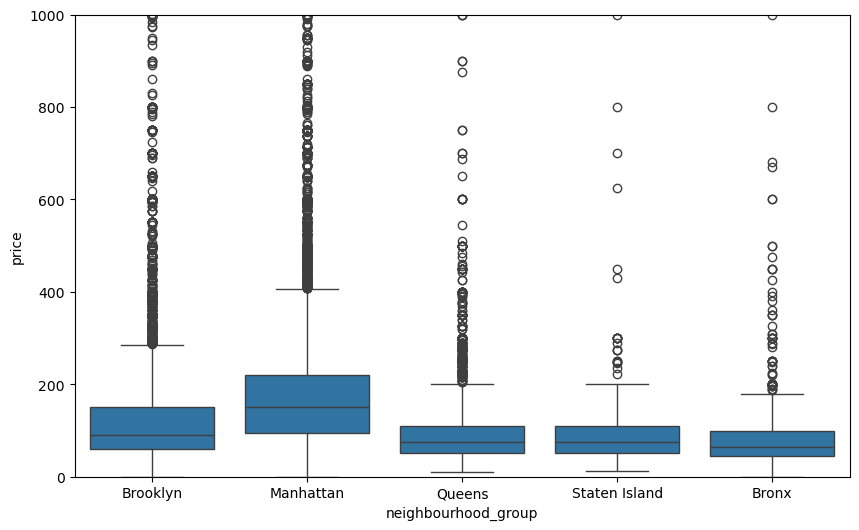

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)

plt.ylim(0,1000)

plt.show()

<Axes: ylabel='neighbourhood_group'>

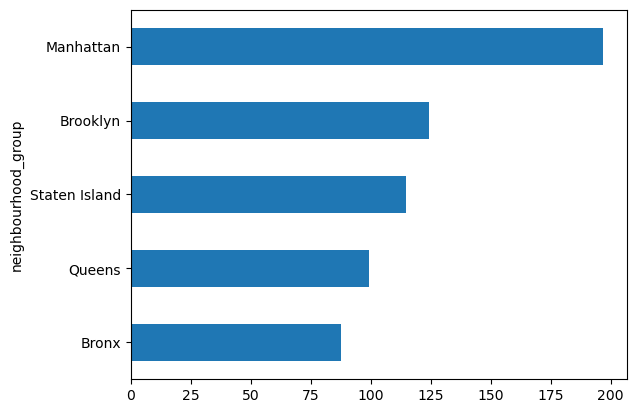

In [9]:
borough_price = (
    df.groupby('neighbourhood_group')
    ['price']
    .mean()
    .sort_values()
)

borough_price.plot.barh()

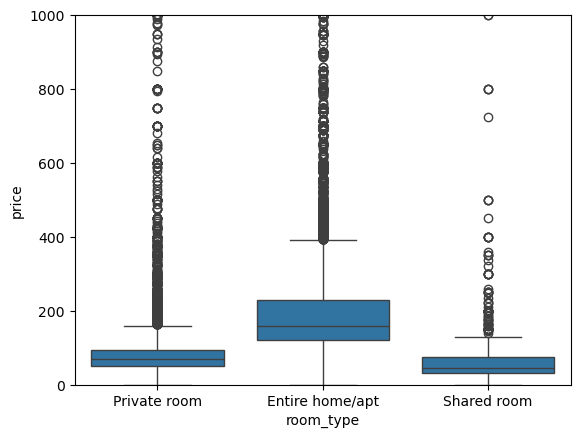

In [10]:
sns.boxplot(
    data=df,
    x='room_type',
    y='price'
)

plt.ylim(0,1000)

plt.show()

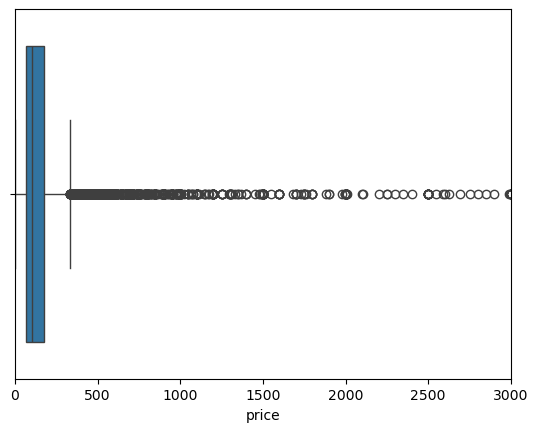

In [11]:
df.sort_values(
    'price',
    ascending=False
).head(20)
sns.boxplot(
    x=df['price']
)

plt.xlim(0,3000)

plt.show()

<Axes: xlabel='neighbourhood_group'>

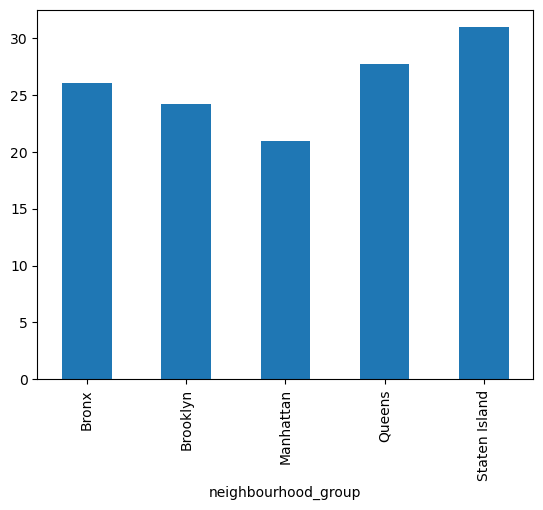

In [12]:
area_reviews = (
    df.groupby(
        'neighbourhood_group'
    )
    ['number_of_reviews']
    .mean()
)

area_reviews.plot.bar()

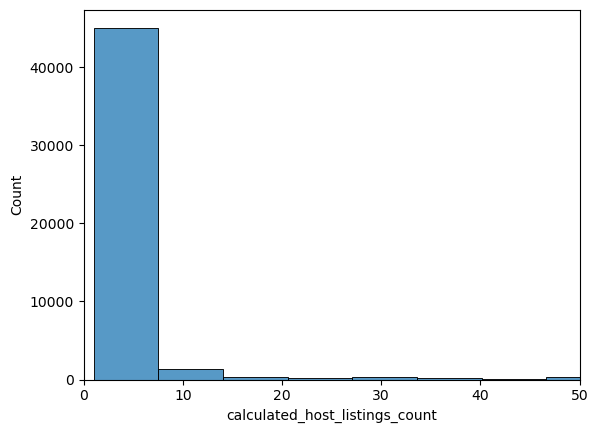

In [13]:
sns.histplot(
    df['calculated_host_listings_count'],
    bins=50
)

plt.xlim(0,50)

plt.show()

<Axes: ylabel='host_name'>

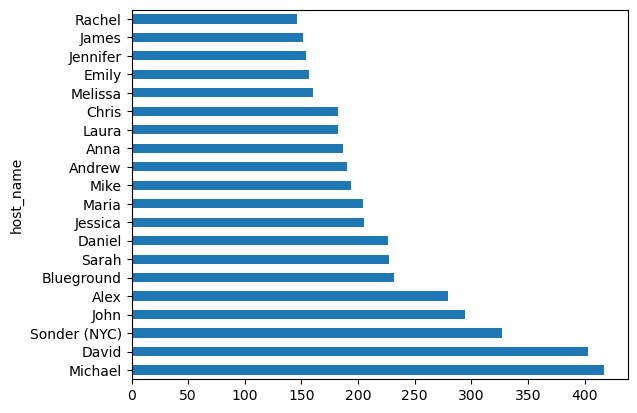

In [15]:
top_hosts = (
    df.groupby('host_name')
    ['id']
    .count()
    .sort_values(
        ascending=False
    )
    .head(20)
)
top_hosts.plot.barh()

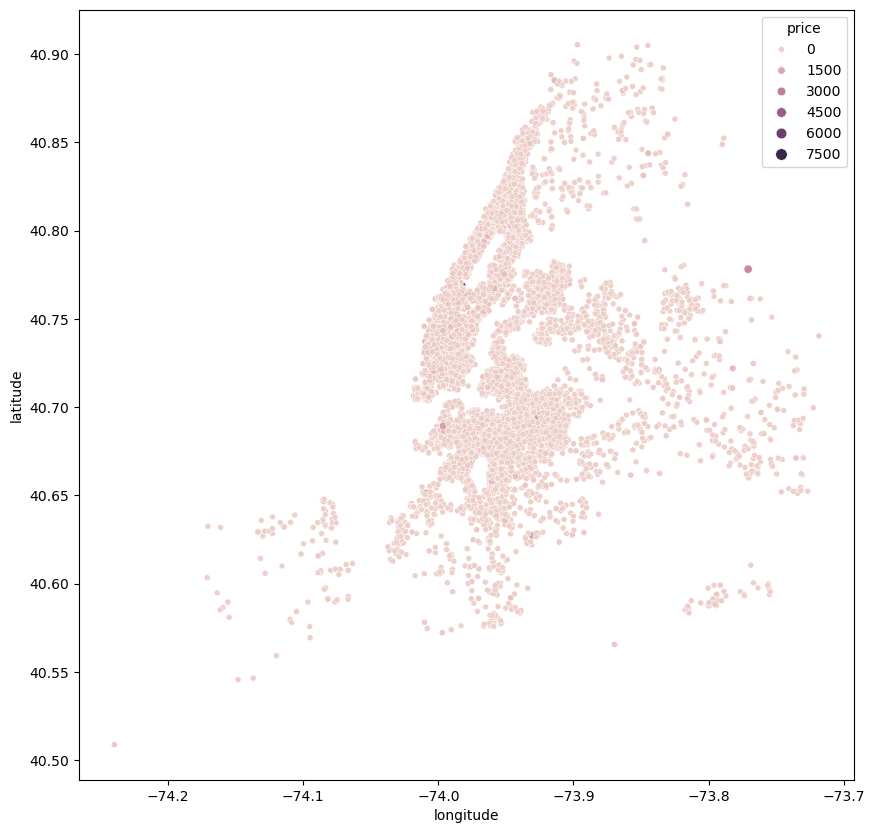

In [16]:
plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df.sample(10000),
    x='longitude',
    y='latitude',
    hue='price',
    size='price'
)

plt.show()

<Axes: xlabel='availability_365', ylabel='Count'>

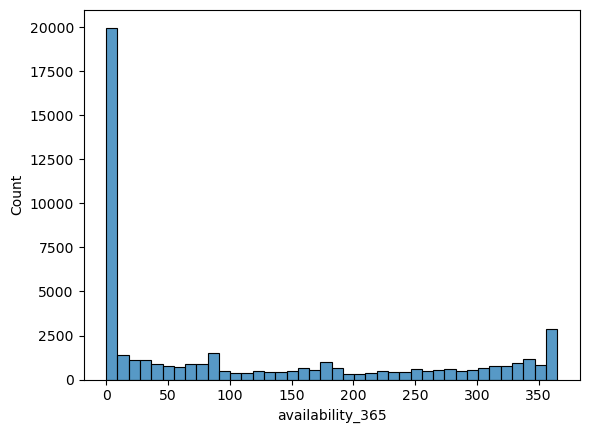

In [17]:
sns.histplot(
    df['availability_365'],
    bins=40
)

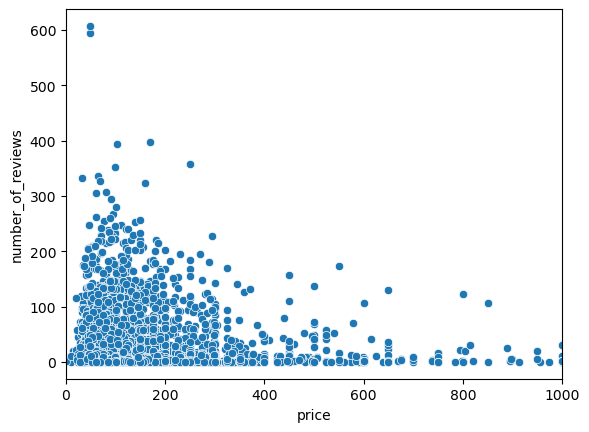

In [20]:
sns.scatterplot(
    data=df.sample(5000),
    x='price',
    y='number_of_reviews'
)

plt.xlim(0,1000)

plt.show()

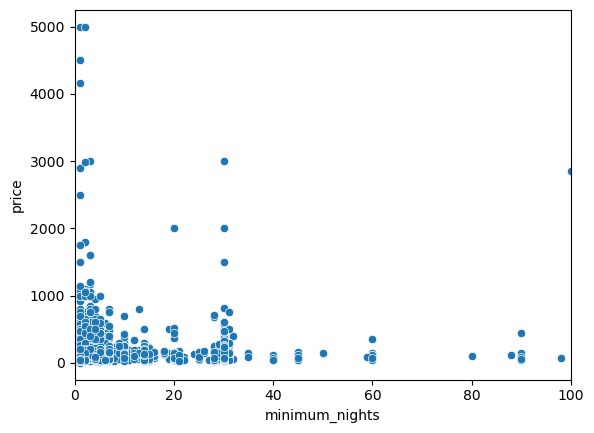

In [21]:
sns.scatterplot(
    data=df.sample(5000),
    x='minimum_nights',
    y='price'
)

plt.xlim(0,100)

plt.show()

<Axes: >

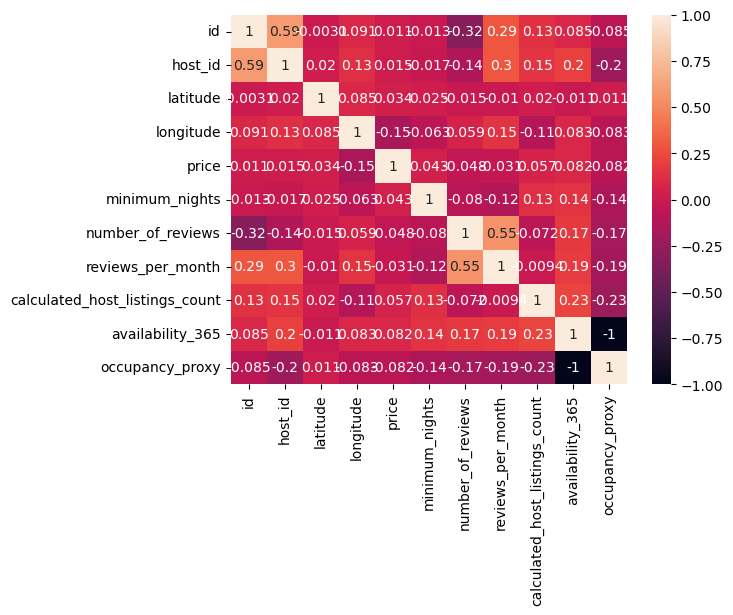

In [22]:
corr = (
    df.select_dtypes(
        include=np.number
    )
    .corr()
)

sns.heatmap(
    corr,
    annot=True
)

<Axes: ylabel='neighbourhood'>

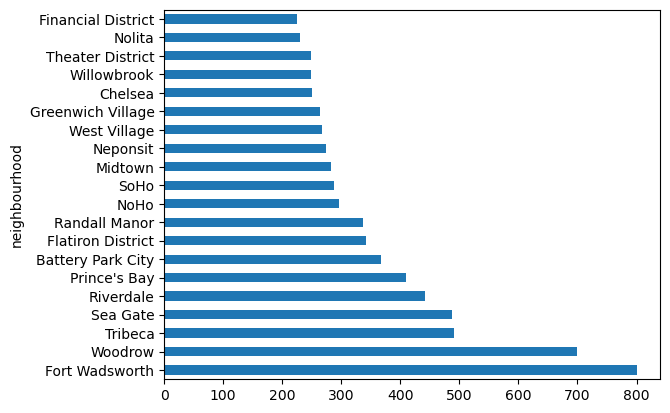

In [24]:
top_neighbourhoods = (
    df.groupby(
        'neighbourhood'
    )
    ['price']
    .mean()
    .sort_values(
        ascending=False
    )
    .head(20)
)
top_neighbourhoods.plot.barh()

<Axes: xlabel='id', ylabel='number_of_reviews'>

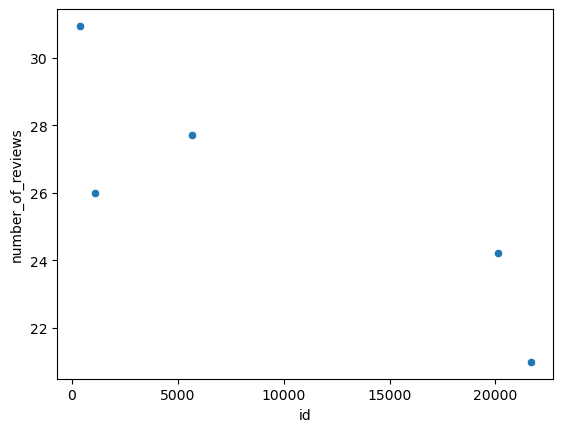

In [25]:
neigh = df.groupby(
    'neighbourhood_group'
).agg({
    'id':'count',
    'number_of_reviews':'mean'
})
sns.scatterplot(
    data=neigh,
    x='id',
    y='number_of_reviews'
)

<Axes: xlabel='neighbourhood_group'>

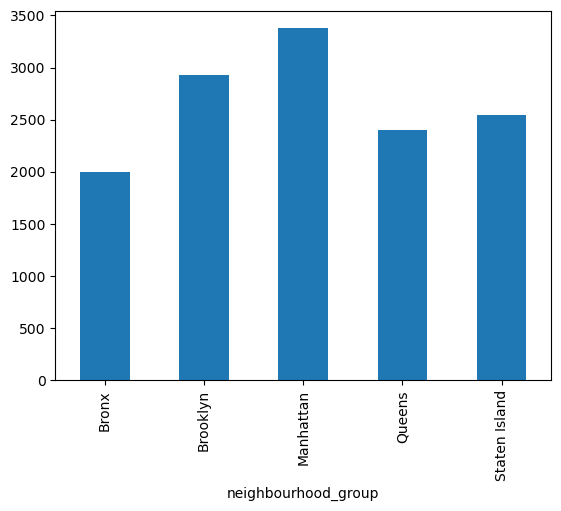

In [26]:
df['Revenue_Proxy'] = (
    df['price']
    *
    df['number_of_reviews']
)
top_areas = (
    df.groupby(
        'neighbourhood_group'
    )
    ['Revenue_Proxy']
    .mean()
)
top_areas.plot.bar()